# Notebook — JAIR Scenario (Jiminy)

This notebook shows how to run the `jair_base.yaml` scenario with different semantics.

---

## Imports

In [1]:
import sys
import os

# Adjust the path if you are in notebooks/
sys.path.append(os.path.abspath(".."))

from jiminy.yaml_loader import load_scenario
from jiminy.engine import Jiminy

In [2]:

(
    possible_facts,
    norms,
    contrariness,
    priorities,
    context_desc,
    norm_desc,
    contrariness_desc,
    priority_desc,
    base_priorities,
    meta_priorities
) = load_scenario("../scenarios/jair_base.yaml")

[INFO] Base priorities loaded: 3
[INFO] Meta-priority rules loaded: 3


In [3]:
J = Jiminy(
    norms,
    contrariness,
    priorities,
    context_desc,
    norm_desc,
    contrariness_desc,
    priority_desc,
    base_priorities,
    meta_priorities
)

In [4]:
context = ["w1", "w2", "w3", "w4"]

args = J.generate_arguments(context)



In [5]:
E, P, O = J.compute_jiminy(context)
accepted_heads = E | P | O

# Build the accepted/rejected arguments from the classic two-phase result
args = J.generate_arguments(context)
accepted = [A for A in args if A.hd in accepted_heads]
rejected = [A for A in args if A.hd not in accepted_heads]

print(J.explain(accepted, rejected, context, semantics="jiminy"))

#Si están en la relación de contrarierad no debería pintartse los dos con línea roja.  Siempre que haya un ataque hay qu erevisar la linea gorda.


CONTEXT ANALYSIS
------------------------------------------------------------
 - w1
 - w2
 - w3
 - w4

GENERATED ARGUMENTS
------------------------------------------------------------
 - ('w4',) ⇒ i_registered (Institutional fact, stakeholder=Manuf)
 - ('w2',) ⇒ i_collects_data (Institutional fact, stakeholder=Law)
 - ('w3',) ⇒ i_threat (Institutional fact, stakeholder=Law)
 - ('i_collects_data',) ⇒ i_privacy_context (Institutional fact, stakeholder=Household)
 - ('w1',) ⇒ d_compliant (Obligation, stakeholder=Law)
 - ('i_registered',) ⇒ d_gdpr (Obligation, stakeholder=Law)
 - ('i_collects_data',) ⇒ d_protect_privacy (Obligation, stakeholder=Household)
 - ('i_threat',) ⇒ d_report (Obligation, stakeholder=Household)
 - ('i_threat',) ⇒ d_collect_no_consent (Permission, stakeholder=Manuf)

DETECTED CONFLICTS
------------------------------------------------------------
 - d_compliant conflicts with: d_collect_no_consent
 - d_gdpr conflicts with: d_collect_no_consent
 - d_protect_privacy con

In [6]:
args = J.generate_arguments(context)
accepted, rejected = J.compute_extension(args, semantics="priority")
print(J.explain(accepted, rejected, context, semantics="priority"))

>>> Semantics received: 'priority'
>>>>>>>>>>> [TIMING] Semantic computation time: 0.000158 seconds
CONTEXT ANALYSIS
------------------------------------------------------------
 - w1
 - w2
 - w3
 - w4

GENERATED ARGUMENTS
------------------------------------------------------------
 - ('w4',) ⇒ i_registered (Institutional fact, stakeholder=Manuf)
 - ('w2',) ⇒ i_collects_data (Institutional fact, stakeholder=Law)
 - ('w3',) ⇒ i_threat (Institutional fact, stakeholder=Law)
 - ('i_collects_data',) ⇒ i_privacy_context (Institutional fact, stakeholder=Household)
 - ('w1',) ⇒ d_compliant (Obligation, stakeholder=Law)
 - ('i_registered',) ⇒ d_gdpr (Obligation, stakeholder=Law)
 - ('i_collects_data',) ⇒ d_protect_privacy (Obligation, stakeholder=Household)
 - ('i_threat',) ⇒ d_report (Obligation, stakeholder=Household)
 - ('i_threat',) ⇒ d_collect_no_consent (Permission, stakeholder=Manuf)

DETECTED CONFLICTS
------------------------------------------------------------
 - d_compliant conflict

In [7]:
J.meta_priorities = []

args = J.generate_arguments(context)
accepted, rejected = J.compute_extension(args, semantics="priority")
print(J.explain(accepted, rejected, context, semantics="base"))

>>> Semantics received: 'priority'
>>>>>>>>>>> [TIMING] Semantic computation time: 0.000140 seconds
CONTEXT ANALYSIS
------------------------------------------------------------
 - w1
 - w2
 - w3
 - w4

GENERATED ARGUMENTS
------------------------------------------------------------
 - ('w4',) ⇒ i_registered (Institutional fact, stakeholder=Manuf)
 - ('w2',) ⇒ i_collects_data (Institutional fact, stakeholder=Law)
 - ('w3',) ⇒ i_threat (Institutional fact, stakeholder=Law)
 - ('i_collects_data',) ⇒ i_privacy_context (Institutional fact, stakeholder=Household)
 - ('w1',) ⇒ d_compliant (Obligation, stakeholder=Law)
 - ('i_registered',) ⇒ d_gdpr (Obligation, stakeholder=Law)
 - ('i_collects_data',) ⇒ d_protect_privacy (Obligation, stakeholder=Household)
 - ('i_threat',) ⇒ d_report (Obligation, stakeholder=Household)
 - ('i_threat',) ⇒ d_collect_no_consent (Permission, stakeholder=Manuf)

DETECTED CONFLICTS
------------------------------------------------------------
 - d_compliant conflict

In [8]:
accepted, rejected = J.compute_extension(context, semantics="naive")
print(J.explain(accepted, rejected, context, semantics="naive"))

>>> Semantics received: 'naive'
CONTEXT ANALYSIS
------------------------------------------------------------
 - w1
 - w2
 - w3
 - w4

GENERATED ARGUMENTS
------------------------------------------------------------
 - ('w4',) ⇒ i_registered (Institutional fact, stakeholder=Manuf)
 - ('w2',) ⇒ i_collects_data (Institutional fact, stakeholder=Law)
 - ('w3',) ⇒ i_threat (Institutional fact, stakeholder=Law)
 - ('i_collects_data',) ⇒ i_privacy_context (Institutional fact, stakeholder=Household)
 - ('w1',) ⇒ d_compliant (Obligation, stakeholder=Law)
 - ('i_registered',) ⇒ d_gdpr (Obligation, stakeholder=Law)
 - ('i_collects_data',) ⇒ d_protect_privacy (Obligation, stakeholder=Household)
 - ('i_threat',) ⇒ d_report (Obligation, stakeholder=Household)
 - ('i_threat',) ⇒ d_collect_no_consent (Permission, stakeholder=Manuf)

DETECTED CONFLICTS
------------------------------------------------------------
 - d_compliant conflicts with: d_collect_no_consent
 - d_gdpr conflicts with: d_collect_no_

## Argumentation attack diagram (attacks and winners)

Attack relations between contrary heads. Because contrariety is symmetric, a contrary
pair is drawn with **two red** chi edges (one in each direction). Nodes with a **double
border** are the winners under the `jiminy` semantics.

Winners here are the heads of `E | P | O` computed by `compute_jiminy`.


[INFO] Base priorities loaded: 3
[INFO] Meta-priority rules loaded: 3
[Visualizer] Rendering graph → jair_base_af.png


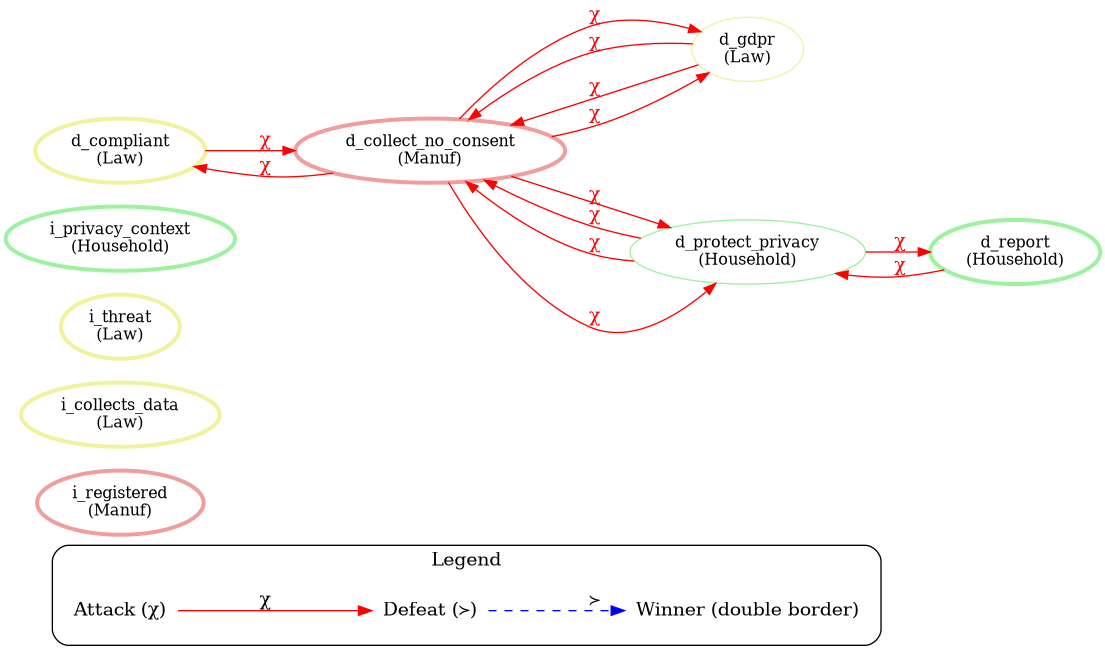

=== Winner heads (accepted) ===
['d_collect_no_consent', 'd_compliant', 'd_report', 'i_collects_data', 'i_privacy_context', 'i_registered', 'i_threat', 'w1', 'w2', 'w3', 'w4']
=== Attack relations (chi) present ===
  d_gdpr  <->  d_collect_no_consent
  d_collect_no_consent  <->  d_gdpr
  d_collect_no_consent  <->  d_protect_privacy
  d_protect_privacy  <->  d_collect_no_consent
  d_report  <->  d_protect_privacy
  d_compliant  <->  d_collect_no_consent


In [9]:
from IPython.display import Image, display
from jiminy.visualization.argumentation_visualizer import ArgumentationVisualizer

(
    possible_facts, norms, contrariness, priorities,
    context_desc, norm_desc, contrariness_desc, priority_desc,
    base_priorities, meta_priorities
) = load_scenario("../scenarios/jair_base.yaml")

J2 = Jiminy(norms, contrariness, priorities, context_desc, norm_desc,
            contrariness_desc, priority_desc, base_priorities, meta_priorities)

E, P, O = J2.compute_jiminy(context)
accepted_heads = E | P | O
args = J2.generate_arguments(context)

av = ArgumentationVisualizer()
av.build_graph(arguments=args, winners={a.hd for a in args if a.hd in accepted_heads},
               priorities=J2.priorities, contrariness=J2.contrariness)
name = "jair_base_af"
av.render(name)
display(Image(filename=f"{name}.png"))

print("=== Winner heads (accepted) ===")
print(sorted(accepted_heads))
print("=== Attack relations (chi) present ===")
for src, contraries in J2.contrariness.items():
    for c in contraries:
        if c in {a.hd for a in args}:
            print(f"  {src}  <->  {c}")
